In [1]:
config_path = "configs/distFlow33_config.yaml" 
dim_state = 32
out_dir = "figures_varying"

In [2]:
import numpy as np
import cvxpy as cp
from configs.config_loader import ConfigLoader
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pfmodels import PFModel, LinDistFlow, DistFlow
from src.utils.case_loader import load_case_from_files
from src.controllers.voltvar_controllers import DistributedVoltVarController
from src.analysis.plot_tools import save_results
from pathlib import Path
import json
import datetime
import pickle
import warnings
from typing import Optional, List, Dict, Any, Tuple, Union, Type
from plot_util import add_zoom_inset_auto,compute_ylim,plot_pts_for_seed
from utilfuncs import has_nan, get_v_ctrl_from_sol,func_grad_u, func_cost1, load_kvec_from_pckl_simple
from convrelax import VoltVarController, CentralizedVoltVarController
from dataloaders import prepare_inputs_with_measurements
np.random.seed(42)


## config

In [3]:
config_path = "distFlow33_config.yaml" 
config_loader = ConfigLoader(config_path)
model_config = config_loader.get_model_config()
load_dir = './src/cases/pypower'
pf_model_type = model_config['pf_model']
case_name = model_config['case']
my_case = load_case_from_files(load_dir,case_name)
pf_model = DistFlow(my_case)
n_bus = pf_model.n_bus
p = -my_case['bus'][1:,2].reshape(-1,1)/my_case['baseMVA']-0.001*np.random.uniform(low=0.5, high=1.0, size=(32,1))
q = -my_case['bus'][1:,3].reshape(-1,1)/my_case['baseMVA']
# Setup controllers
dis_vv_controllers = DistributedVoltVarController(config_loader) # All the settings can be found in default_config
controlled_nodes = dis_vv_controllers.nodes
# Run pf once
sol = pf_model.runpf(p,q)
new_p = p
sol_list = []
sol_list.append(sol)
for t in range(1):
    v_list = sol_list[-1]['v']
    v_dict = {node:v_list[node] for node in controlled_nodes}
    q_commend = dis_vv_controllers.get_q(v_dict)
    new_q = q
    new_p = new_p+np.clip(np.random.randn(n_bus-1,1)*(10**(-4)),-8*10**(-5),8*10**(-5))
    for node, q_injection in q_commend.items():
        new_q[node] += q_injection
    sol = pf_model.runpf(new_p,new_q)
    sol_list.append(sol)
q_init = new_q.copy()
p_init = new_p.copy()
dis_vv_controllers = DistributedVoltVarController(config_loader) 
controlled_nodes = dis_vv_controllers.nodes

## Env setup

In [4]:
dim_action = np.size(controlled_nodes)
dim_state = n_bus
dim_obs = dim_action
PredictLength = 20
sigma_e = 0.01
SimulationLength=dim_state+PredictLength*(dim_action+1)-1+1000
List_noise = 0.1*np.random.normal(np.zeros((dim_action, SimulationLength+100)), sigma_e)
List_noise_state = 0.2*np.clip(np.random.randn(n_bus-1,SimulationLength+100)*(10**(-4)),-8*10**(-5),8*10**(-5))
s_ref = np.ones((1, dim_action))
C_ACTION = 0.1
R_U = None
Q_ABS_MAX = 0.05  
Sens_length = 100
Opt_length = 50
T = Sens_length + Opt_length

with open('./DataPred_n17_normalized.pkl', 'rb') as f:
    data_pred = pickle.load(f)
num_nodes, time_steps = data_pred.shape
control_nodes = list(range(0,32))
num_control_nodes = len(control_nodes)
s_ref_ctrl = np.asarray(s_ref, dtype=float).reshape(-1)


In [5]:
step_tspan=[(109,151),(119,151),(139,151)]
p_ts, p_init, q_init, mapping, start_idx_used = prepare_inputs_with_measurements(
    data_pred=data_pred,
    control_nodes=control_nodes,
    timehorizon=350,
    p_init=p_init,
    q_init=q_init,
    seed=42,
    start_idx=None,
    replace=None,
    scale_factor=2,
    add_step=True,
    step_nodes=None,                          
    step_tspan=step_tspan,
    step_delta=None,                          
    step_frac=[0.4,0.4,0.2],                            
    step_direction= ["decrease",'decrease','increase'],
    clip_pu=None                              
)

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/2789340535.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(plotlist))


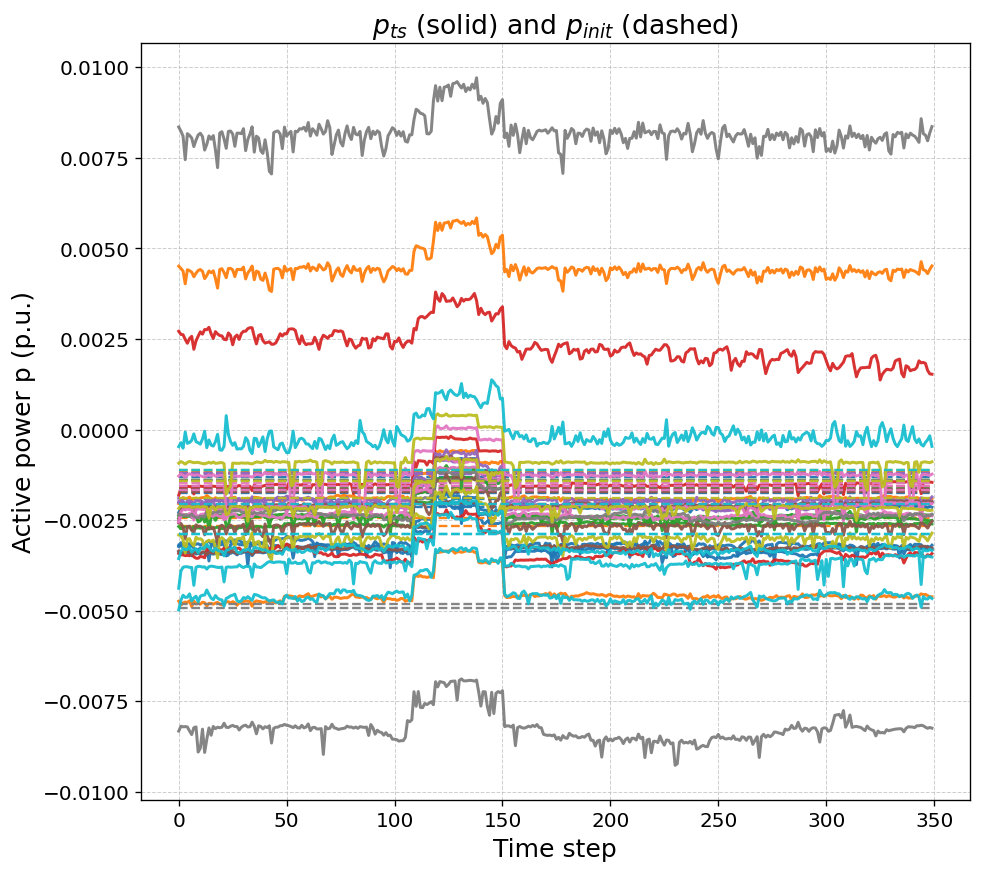

In [6]:
p_ts   = np.asarray(p_ts, dtype=float)
p_init = np.asarray(p_init, dtype=float).reshape(-1, 1)
n_nodes, n_steps = p_ts.shape
time_idx = np.arange(n_steps)
p_init_time = np.repeat(p_init, n_steps, axis=1)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
fig, ax = plt.subplots(figsize=(10.5, 7.5), dpi=120)
plotlist = range(n_nodes)
cmap = plt.cm.get_cmap("tab10", len(plotlist))
colors = [cmap(i) for i in range(len(plotlist))]
for k, node_idx in enumerate(plotlist):
    if node_idx < 0 or node_idx >= n_nodes:
        continue
    ax.plot(time_idx, p_ts[node_idx, :], lw=1.8, alpha=0.95,
            color=colors[k], label=f"dim {node_idx} (p_ts)")
    ax.plot(time_idx, p_init_time[node_idx, :], lw=1.4, alpha=0.95, ls="--",
            color=colors[k], label=f"dim {node_idx} (p_init)")
ax.set_xlabel("Time step")
ax.set_ylabel("Active power p (p.u.)")
ax.set_title("$p_{ts}$ (solid) and $p_{init}$ (dashed)")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
handles, labels = ax.get_legend_handles_labels()
kept = []
seen = set()
for h, lab in zip(handles, labels):
    try:
        dim = int(lab.split()[1])
    except Exception:
        dim = lab
    key = (dim, lab.endswith("(p_ts)"))
    if key not in seen:
        kept.append((h, lab))
        seen.add(key)

# leg = ax.legend(*zip(*kept),
#                 loc='center left',
#                 bbox_to_anchor=(1.02, 0.5),
#                 borderaxespad=0.0,
#                 frameon=True,
#                 ncol=1)

plt.tight_layout(rect=(0, 0, 0.80, 1))
plt.show()

# Linear Control

In [7]:
controlled_nodes = np.asarray(controlled_nodes, dtype=int).ravel()
m = controlled_nodes.size
k_file = "src/cases/pypower/case33/linear_k.pckl"

K_vec = load_kvec_from_pckl_simple(k_file, controlled_nodes)
K = np.diag(K_vec)  # (m, m)

sol_list = []
record_cost_lin = []         
Record_u_Linear_lin = []      
Trajectory_Linear_lin = []    
p_init = np.asarray(p_init, float).reshape(-1, 1)   # (n_bus, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)   # (n_bus, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_ts[:, t].reshape(-1, 1)   
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)  # (m, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu  
    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)          # (1, m)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)               # (m, 1)

    Record_u_Linear_lin.append(q_ctrl.ravel().copy())
    Trajectory_Linear_lin.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,                     # (1, m)
        s_ref.reshape(1, -1),       # (1, m)
        q_ctrl,                     # (m, 1)
        c_action=C_ACTION,
        R_u=R_U,
    )
    record_cost_lin.append(float(c))

for t in range(Sens_length, T):
    new_p = p_ts[:, t].reshape(-1, 1)   
    sol_last = sol_list[-1]
    v_ctrl_last = get_v_ctrl_from_sol(sol_last, controlled_nodes)   # (1, m)
    v_vec = v_ctrl_last.reshape(-1, 1)          # (m, 1)
    s_vec = s_ref.reshape(-1, 1)                # (m, 1)
    e = v_vec - s_vec                           # (m, 1)
    q_next = - (K @ e)                          # (m, 1)
    q_next = np.clip(q_next, -Q_ABS_MAX, Q_ABS_MAX)
    new_q[controlled_nodes] = q_next
    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)            # (1, m)
    if has_nan(v_ctrl):
        print("v nan, break at t=", t)
        break

    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)                 # (m, 1)

    Record_u_Linear_lin.append(q_ctrl.ravel().copy())
    Trajectory_Linear_lin.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U,
    )
    record_cost_lin.append(float(c))

linear_logs = {
    "sol_list": sol_list,
    "record_cost_linear": record_cost_lin,
    "record_cost_linear_opt": record_cost_lin[Sens_length:],
    "Record_u_Linear_linear": Record_u_Linear_lin,
    "Trajectory_Linear_linear": Trajectory_Linear_lin,
}


Linear Control


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/3232102263.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(selected_cols))


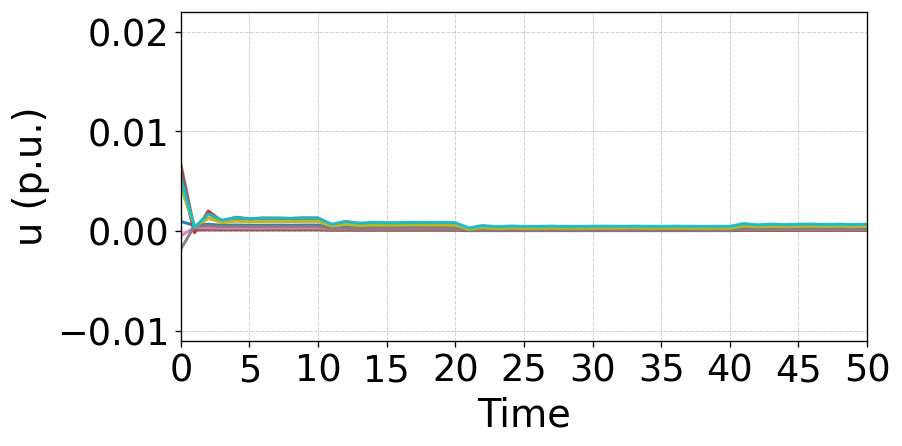

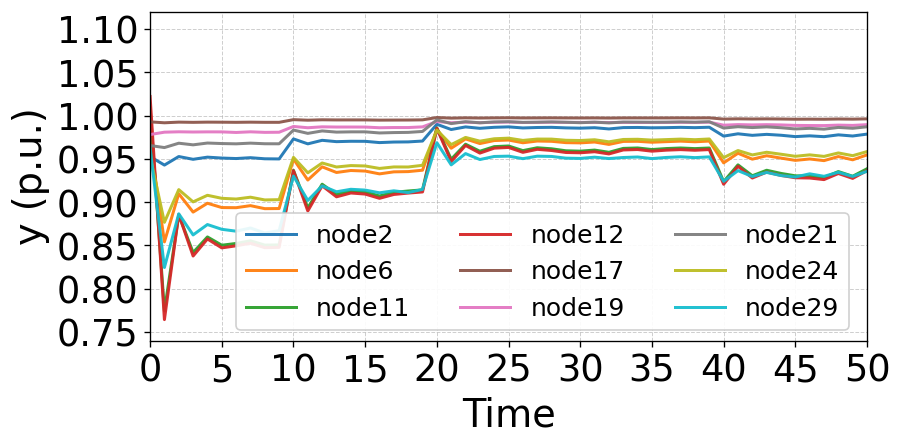

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/3232102263.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


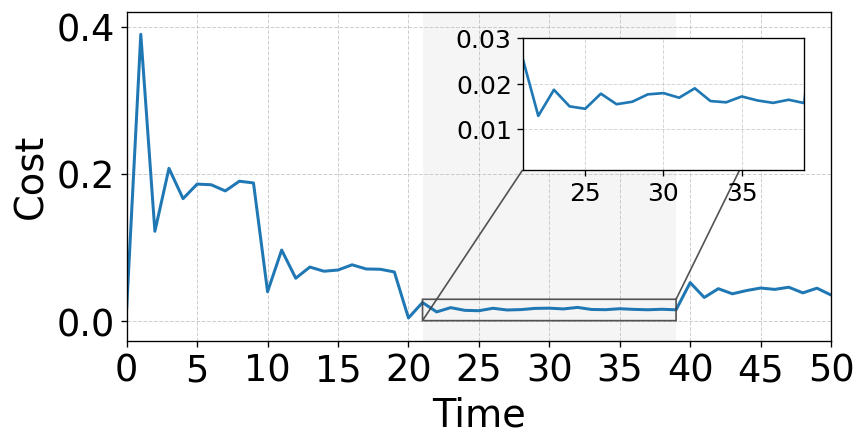

Saved to:
 - figures_varying/LIN_actions-Varying_9nodes.pdf
 - figures_varying/LIN_voltages-Varying_9nodes.pdf
 - figures_varying/LIN_cost-Varying.pdf


In [8]:
print("Linear Control")

MANUAL_Y = {
    "action":  (-0.011,0.022),
    "voltage": (0.74, 1.12),
    "cost":   None,
}
FORCE_SYMM = {
    "action":  False,   
    "voltage": False,
    "cost":    False,
}

Trajectory_Linear_lin = np.squeeze(np.asarray(Trajectory_Linear_lin))
Record_u_Linear_lin   = np.squeeze(np.asarray(Record_u_Linear_lin))
record_cost_lin       = np.asarray(record_cost_lin).ravel()

N_total = Record_u_Linear_lin.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost    = max(0, Sens_length - 1)
idx_cost      = slice(start_cost, N_total)
time_seg_cost = np.arange(0, Opt_length_pretty + 1)

zoom_range = (21, 39)

os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 23,
    "axes.labelsize": 23,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})

Y_action  = Record_u_Linear_lin[idx_opt, :]
Y_voltage = Trajectory_Linear_lin[idx_opt, :]
Y_cost    = record_cost_lin[idx_cost]

ylim_action  = compute_ylim(
    [Y_action], MANUAL_Y["action"],
    pad_frac=0.06, symmetric=FORCE_SYMM["action"]
)
ylim_voltage = compute_ylim(
    [Y_voltage], MANUAL_Y["voltage"],
    pad_frac=0.03, symmetric=FORCE_SYMM["voltage"]
)
ylim_cost    = compute_ylim(
    [Y_cost], MANUAL_Y["cost"],
    pad_frac=0.08, symmetric=FORCE_SYMM["cost"]
)

xticks_main = np.arange(0, Opt_length_pretty + 1, 5)
T_opt, n_ctrl = Y_voltage.shape
target_num = min(9, n_ctrl)
rng = np.random.default_rng(42)
selected_cols = np.sort(
    rng.choice(np.arange(n_ctrl, dtype=int), size=target_num, replace=False)
)

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    node_ids_for_plot = np.asarray(controlled_nodes, dtype=int)[selected_cols]
else:
    node_ids_for_plot = selected_cols

sel_path = os.path.join(out_dir, "varying_nodes_seed42.npy")
np.save(sel_path, node_ids_for_plot)

Y_action_sel = Y_action[:, selected_cols]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)

cmap = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)

plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "LIN_actions-Varying_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

Y_voltage_sel = Y_voltage[:, selected_cols]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)

for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    bbox_transform=ax.transAxes,
    borderaxespad=0.15,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=15.0
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "LIN_voltages-Varying_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color="grey", alpha=0.08, linewidth=0)

add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(1e-3, 0.03),  
)

plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "LIN_cost-Varying.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")

# feedback optimizaiton

In [9]:
dis_vv_controllers = DistributedVoltVarController(config_loader)  
controlled_nodes = np.asarray(dis_vv_controllers.nodes, dtype=int).ravel()
sol_list = []
record_cost_gd = []
Record_u_Linear_gd = []
record_grad_v_u = []
record_grad_u = []
Trajectory_Linear_gd = []
lr0 = 5e-3
decay_rate_lr = 0.02
p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):
    new_p = p_ts[:, t].reshape(-1, 1)  
    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu
    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)
    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)
    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))

decay_rate = 0.1
sens_coeff = 1 - np.exp(-decay_rate * np.arange(1, Sens_length))

for t in range(Sens_length, T):
    lr = lr0 * (np.exp(-decay_rate_lr * t))
    new_p = p_ts[:, t].reshape(-1, 1)

    U_win = np.asarray(Record_u_Linear_gd[t - Sens_length:t], dtype=float)
    V_win = np.asarray(
        np.squeeze(np.asarray(Trajectory_Linear_gd))[t - Sens_length:t],
        dtype=float
    )

    Diff_u = np.diff(U_win, axis=0)
    Diff_x = np.diff(V_win, axis=0)
    if Diff_u.ndim == 1:
        Diff_u = Diff_u.reshape(-1, 1)
    if Diff_x.ndim == 1:
        Diff_x = Diff_x.reshape(-1, 1)

    W = np.diag(sens_coeff)
    A = W @ Diff_u
    B = W @ Diff_x

    AtA = A.T @ A
    AtB = A.T @ B
    mu_base = 0
    scale = np.trace(AtA) / max(1, AtA.shape[0]) if AtA.size else 1.0
    mu = 0
    S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
    J_v_u_estimate = S_T.T

    sol_curr = sol_list[-1]
    v_curr = get_v_ctrl_from_sol(sol_curr, controlled_nodes)

    grad_u = func_grad_u(
        v_curr,
        s_ref.reshape(1, -1),
        J_v_u_estimate,
        new_q[controlled_nodes],
        c_action=C_ACTION,
        R_u=R_U
    )
    if has_nan(np.asarray(grad_u)):
        print('grad_u nan, break at t=', t)
        break

    q_next = new_q[controlled_nodes] - lr * grad_u.reshape((-1, 1))
    new_q[controlled_nodes] = np.clip(q_next, -Q_ABS_MAX, Q_ABS_MAX)

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    if has_nan(v_ctrl):
        print('v nan, break at t=', t)
        break

    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_gd.append(q_ctrl.ravel().copy())
    Trajectory_Linear_gd.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_gd.append(float(c))


Feedback Optimization


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/481067231.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(selected_cols))


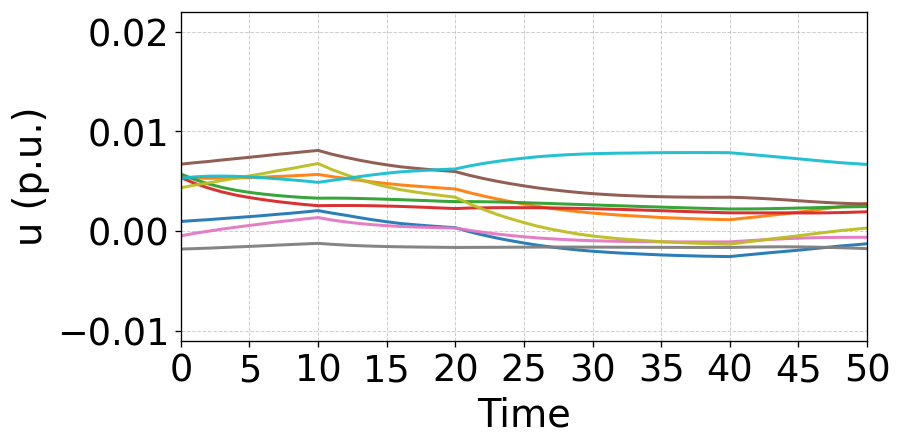

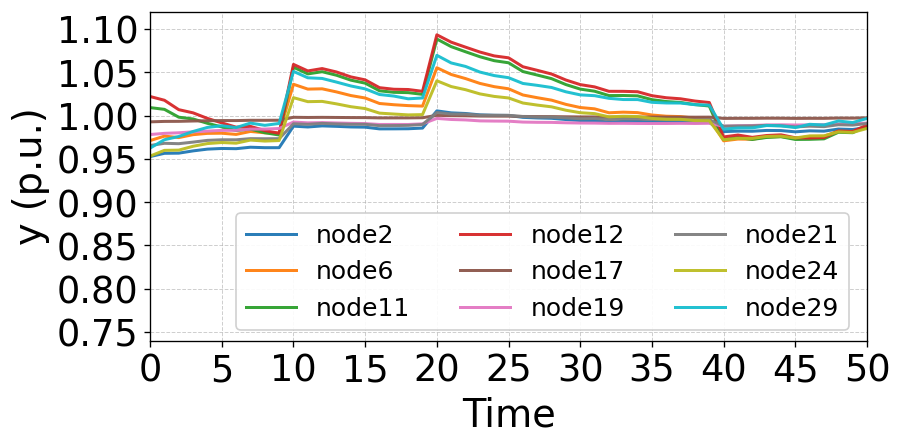

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/481067231.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


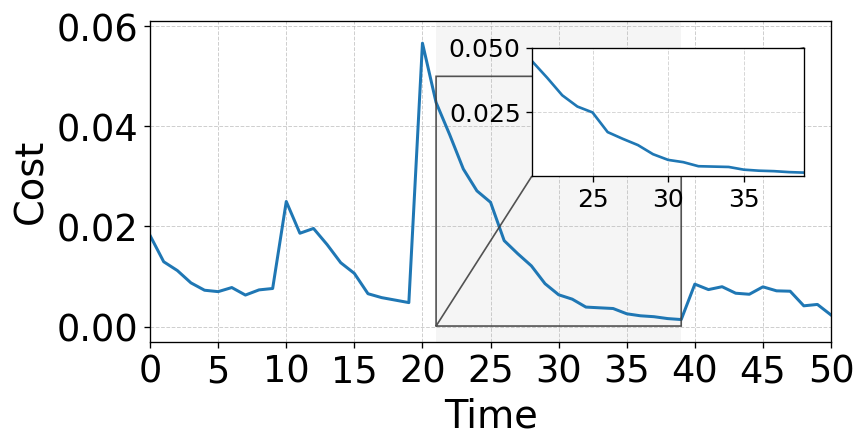

Saved to:
 - figures_varying/GD_actions-Varying_9nodes.pdf
 - figures_varying/GD_voltages-Varying_9nodes.pdf
 - figures_varying/GD_cost-Varying.pdf


In [10]:
print('Feedback Optimization')

MANUAL_Y = {
    "action":  (-0.011,0.022),
    "voltage": (0.74, 1.12),
    "cost":   None,
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}

def compute_ylim(arr_list, manual=None, *, pad_frac=0.06, symmetric=False, min_span=1e-8):
    if manual is not None:
        y0, y1 = float(manual[0]), float(manual[1])
        if symmetric:
            m = max(abs(y0), abs(y1))
            return (-m, m)
        return (y0, y1)

    y_min, y_max = None, None
    for A in arr_list:
        A = np.asarray(A, dtype=float)
        if A.size == 0:
            continue
        a_min = float(np.nanmin(A))
        a_max = float(np.nanmax(A))
        y_min = a_min if y_min is None else min(y_min, a_min)
        y_max = a_max if y_max is None else max(y_max, a_max)

    if not np.isfinite([y_min, y_max]).all():
        return (-1.0, 1.0)
    if abs(y_max - y_min) < min_span:
        mid = 0.5 * (y_max + y_min)
        y_min, y_max = mid - 0.5, mid + 0.5

    if symmetric:
        m = max(abs(y_min), abs(y_max))
        y_min, y_max = -m, m

    pad = pad_frac * (y_max - y_min)
    return (y_min - pad, y_max + pad)

Trajectory_Linear_gd = np.squeeze(np.asarray(Trajectory_Linear_gd))
Record_u_Linear_gd   = np.squeeze(np.asarray(Record_u_Linear_gd))
record_cost_gd       = np.asarray(record_cost_gd).ravel()

N_total = Record_u_Linear_gd.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost     = max(0, Sens_length - 1)
idx_cost       = slice(start_cost, N_total)
time_seg_cost  = np.arange(0, Opt_length_pretty + 1)

zoom_range = (21, 39)


os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 23,
    "axes.labelsize": 23,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


Y_action  = Record_u_Linear_gd[idx_opt, :]
Y_voltage = Trajectory_Linear_gd[idx_opt, :]
Y_cost    = record_cost_gd[idx_cost]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])
xticks_main = np.arange(0, Opt_length_pretty + 1, 5)
sel_path = os.path.join(out_dir, "varying_nodes_seed42.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for GD.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols

Y_action_sel  = Y_action[:, selected_cols]
Y_voltage_sel = Y_voltage[:, selected_cols]

cmap   = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("u (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)


plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "GD_actions-Varying_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("y (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    bbox_transform=ax.transAxes,
    borderaxespad=0.15,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=15.0
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "GD_voltages-Varying_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)
x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)
add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(0.0001, 0.05),
)
plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "GD_cost-Varying.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")


# Data-Driven Succ Linearization

In [11]:
dis_vv_controllers = DistributedVoltVarController(config_loader)
controlled_nodes = np.asarray(dis_vv_controllers.nodes, dtype=int).ravel()
dim_action = controlled_nodes.size

sol_list = []
record_cost_sc = []
Record_u_Linear_sc = []
record_grad_v_u = []
record_grad_u = []
Trajectory_Linear_sc = []

lr = 0.01
Iter_stop_criterier = 0.001

p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)
new_p  = p_init.copy()
new_q  = q_init.copy()

for t in range(Sens_length):

    new_p = p_ts[:, t].reshape(-1, 1)

    nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
    new_q[controlled_nodes] = q_init[controlled_nodes] + nu

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_sc.append(q_ctrl.ravel().copy())
    Trajectory_Linear_sc.append(v_ctrl.copy())

    c = func_cost1(
        v_ctrl,
        s_ref.reshape(1, -1),
        q_ctrl,
        c_action=C_ACTION,
        R_u=R_U
    )
    record_cost_sc.append(float(c))

decay_rate = 0.1

sens_coeff = 1 - np.exp(-decay_rate * np.arange(1, Sens_length))

for t in range(Sens_length, T):
    new_p = p_ts[:, t].reshape(-1, 1)
    if np.linalg.norm(grad_u) < 0.005:
        v_curr = get_v_ctrl_from_sol(sol_list[-1], controlled_nodes)
        grad_u = func_grad_u(
            v_curr,
            s_ref.reshape(1, -1),
            grad_v_u_estimate,
            new_q[controlled_nodes],
            c_action=C_ACTION,
            R_u=R_U
        )
        new_q[controlled_nodes] = Record_u_Linear_sc[-1].reshape(-1, 1) \
                                  + 0.01 * np.asarray(List_noise[:, t], float).reshape(-1, 1)
    else:
        U_win = np.asarray(Record_u_Linear_sc[t - Sens_length:t], dtype=float)
        V_win = np.asarray(
            np.squeeze(np.asarray(Trajectory_Linear_sc))[t - Sens_length:t],
            dtype=float
        )

        if U_win.ndim == 1:
            U_win = U_win.reshape(-1, 1)
        if V_win.ndim == 1:
            V_win = V_win.reshape(-1, 1)

        Diff_u = np.diff(U_win, axis=0)
        Diff_x = np.diff(V_win, axis=0)

        W = np.diag(sens_coeff)
        A = W @ Diff_u
        B = W @ Diff_x
        AtA = A.T @ A
        AtB = A.T @ B
        mu_base = 0
        scale = np.trace(AtA) / max(1, AtA.shape[0]) if AtA.size else 1.0
        mu = 0
        S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
        grad_v_u_estimate = S_T.T

        sol_curr = sol_list[-1]
        v_curr = get_v_ctrl_from_sol(sol_curr, controlled_nodes)

        grad_u = func_grad_u(
            v_curr,
            s_ref.reshape(1, -1),
            grad_v_u_estimate,
            new_q[controlled_nodes],
            c_action=C_ACTION,
            R_u=R_U
        )

        q_lin = cp.Variable((dim_action, 1))

        objective = cp.Minimize(
            0.5 * cp.norm(
                grad_v_u_estimate @ (q_lin - Record_u_Linear_sc[-1].reshape((-1, 1)))
                + Trajectory_Linear_sc[-1].reshape((-1, 1)) - s_ref.reshape((-1, 1))
            )
            + C_ACTION * cp.norm(q_lin)
        )

        if np.linalg.norm(grad_u) > 5:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.3 * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.25 * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]

        elif np.linalg.norm(grad_u) > 0.2:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.15 * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 1.0 * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]
        elif np.linalg.norm(grad_u) > 0.01:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.01 * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 0.005 * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]

        else:
            constraints = [
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 5 * float(np.linalg.norm(grad_u)) * float(np.linalg.norm(new_q[controlled_nodes])),
                cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                <= 25 * (float(np.linalg.norm(grad_u)) ** 1) * float(np.linalg.norm(grad_u)),
                q_lin >= -Q_ABS_MAX,
                q_lin <= Q_ABS_MAX,
            ]

        prob = cp.Problem(objective, constraints)
        result = prob.solve()

        if (result is None) or np.isnan(result):
            q_next = new_q[controlled_nodes] - lr * np.asarray(grad_u, dtype=float).reshape((-1, 1))
        else:
            q_next = np.array(q_lin.value).reshape((-1, 1))

        new_q[controlled_nodes] = np.clip(
            q_next + 0.001 * np.asarray(List_noise[:, t], float).reshape((-1, 1)),
            -Q_ABS_MAX,
            Q_ABS_MAX
        )

    sol = pf_model.runpf(new_p, new_q)
    sol_list.append(sol)

    v_ctrl = get_v_ctrl_from_sol(sol, controlled_nodes)
    q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

    Record_u_Linear_sc.append(q_ctrl.ravel().copy())
    Trajectory_Linear_sc.append(v_ctrl.copy())
    record_cost_sc.append(
        func_cost1(
            v_ctrl,
            s_ref.reshape(1, -1),
            q_ctrl,
            c_action=C_ACTION,
            R_u=R_U
        )
    )

Data-Driven Successive Linearization


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/1785228491.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(selected_cols))


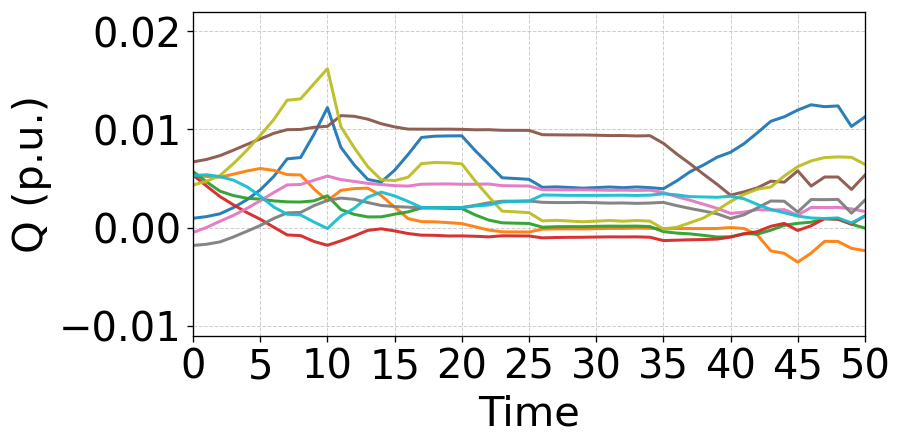

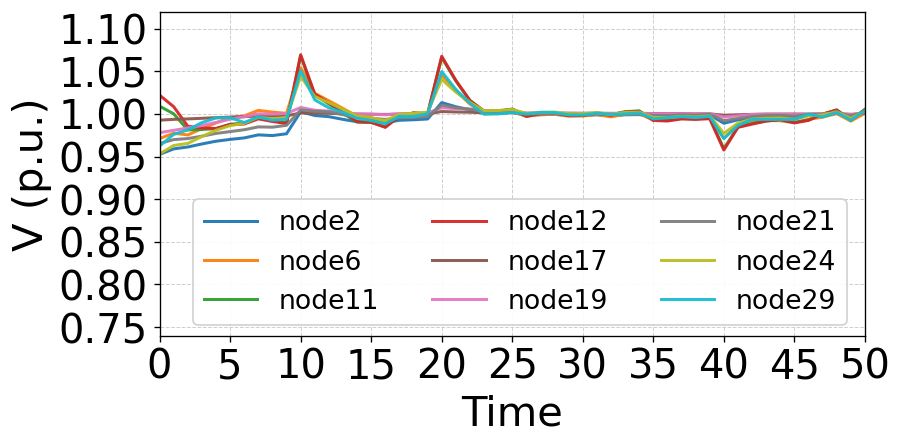

/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/1785228491.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


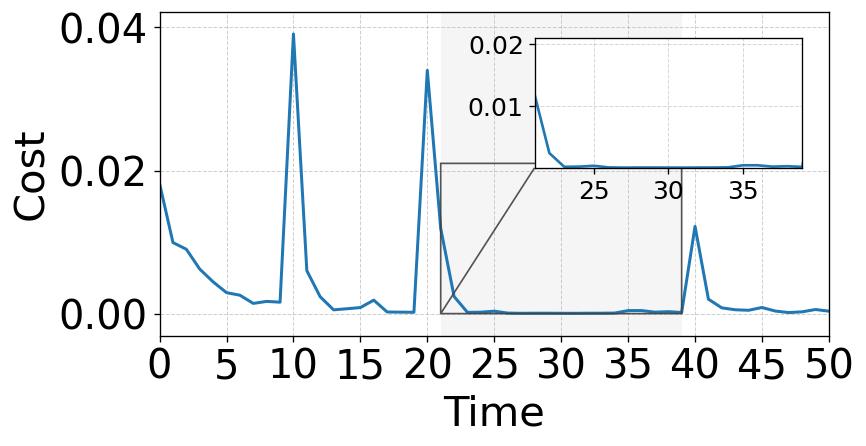

Saved to:
 - figures_varying/SC_actions-Varying_9nodes.pdf
 - figures_varying/SC_voltages-Varying_9nodes.pdf
 - figures_varying/SC_cost-Varying.pdf


In [12]:
print('Data-Driven Successive Linearization')

MANUAL_Y = {
    "action":  (-0.011,0.022),
    "voltage": (0.74, 1.12),
    "cost":   None,
}
FORCE_SYMM = {
    "action":  False,
    "voltage": False,
    "cost":    False,
}

def compute_ylim(arr_list, manual=None, *, pad_frac=0.06, symmetric=False, min_span=1e-8):
    if manual is not None:
        y0, y1 = float(manual[0]), float(manual[1])
        if symmetric:
            m = max(abs(y0), abs(y1))
            return (-m, m)
        return (y0, y1)

    y_min, y_max = None, None
    for A in arr_list:
        A = np.asarray(A, dtype=float)
        if A.size == 0:
            continue
        a_min = float(np.nanmin(A))
        a_max = float(np.nanmax(A))
        y_min = a_min if y_min is None else min(y_min, a_min)
        y_max = a_max if y_max is None else max(y_max, a_max)

    if not np.isfinite([y_min, y_max]).all():
        return (-1.0, 1.0)
    if abs(y_max - y_min) < min_span:
        mid = 0.5 * (y_max + y_min)
        y_min, y_max = mid - 0.5, mid + 0.5

    if symmetric:
        m = max(abs(y_min), abs(y_max))
        y_min, y_max = -m, m

    pad = pad_frac * (y_max - y_min)
    return (y_min - pad, y_max + pad)

Trajectory_Linear_sc = np.squeeze(np.asarray(Trajectory_Linear_sc))
Record_u_Linear_sc   = np.squeeze(np.asarray(Record_u_Linear_sc))
record_cost_sc       = np.asarray(record_cost_sc).ravel()

N_total = Record_u_Linear_sc.shape[0]
Opt_length_pretty = N_total - Sens_length

idx_opt  = slice(Sens_length - 1, N_total)
time_seg = np.arange(0, Opt_length_pretty + 1)

start_cost    = max(0, Sens_length - 1)
idx_cost      = slice(start_cost, N_total)
time_seg_cost = np.arange(0, Opt_length_pretty + 1)

zoom_range = (21, 39)


os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

xticks_main = np.arange(0, Opt_length_pretty + 1, 5)

Y_action  = Record_u_Linear_sc[idx_opt, :]
Y_voltage = Trajectory_Linear_sc[idx_opt, :]
Y_cost    = record_cost_sc[idx_cost]

ylim_action  = compute_ylim([Y_action],  MANUAL_Y["action"],  pad_frac=0.06, symmetric=FORCE_SYMM["action"])
ylim_voltage = compute_ylim([Y_voltage], MANUAL_Y["voltage"], pad_frac=0.03, symmetric=FORCE_SYMM["voltage"])
ylim_cost    = compute_ylim([Y_cost],    MANUAL_Y["cost"],    pad_frac=0.08, symmetric=FORCE_SYMM["cost"])
sel_path = os.path.join(out_dir, "varying_nodes_seed42.npy")
selected_node_ids = np.load(sel_path)
T_opt, n_ctrl = Y_voltage.shape

if "controlled_nodes" in globals() and len(controlled_nodes) == n_ctrl:
    controlled_nodes_arr = np.asarray(controlled_nodes, dtype=int)
    selected_cols = []
    for nid in selected_node_ids:
        matches = np.where(controlled_nodes_arr == nid)[0]
        if matches.size == 0:
            raise ValueError(f"Node ID {nid} not found in controlled_nodes for SC.")
        selected_cols.append(matches[0])
    selected_cols = np.asarray(selected_cols, dtype=int)
    node_ids_for_plot = np.asarray(selected_node_ids, dtype=int)
else:
    selected_cols = np.asarray(selected_node_ids, dtype=int)
    node_ids_for_plot = selected_cols


Y_action_sel  = Y_action[:, selected_cols]
Y_voltage_sel = Y_voltage[:, selected_cols]

cmap   = plt.cm.get_cmap("tab10", len(selected_cols))
colors = [cmap(i) for i in range(len(selected_cols))]

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_action_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("Q (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_action)


plt.tight_layout()
out_pdf1 = os.path.join(out_dir, "SC_actions-Varying_9nodes.pdf")
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.0), dpi=120)
for k, node_id in enumerate(node_ids_for_plot):
    ax.plot(
        time_seg,
        Y_voltage_sel[:, k],
        lw=1.8,
        alpha=0.95,
        color=colors[k],
        label=f"node{int(node_id)}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("V (p.u.)")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_voltage)

vmin, vmax = ax.get_ylim()
vstep = 0.05
vstart = np.ceil(vmin / vstep) * vstep
vy = np.arange(vstart, vmax + 1e-12, vstep)
ax.set_yticks(np.round(vy, 3))

leg = ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    bbox_transform=ax.transAxes,
    borderaxespad=0.15,
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize=16.0
)

plt.tight_layout()
out_pdf2 = os.path.join(out_dir, "SC_voltages-Varying_9nodes.pdf")
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=120)
ax.plot(time_seg_cost, Y_cost, linewidth=1.8)
ax.set_xlabel("Time")
ax.set_ylabel("Cost")
ax.set_xlim(0, Opt_length_pretty)
ax.set_xticks(xticks_main)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_ylim(*ylim_cost)

x0, x1 = zoom_range
x0 = max(0, min(x0, Opt_length_pretty))
x1 = max(0, min(x1, Opt_length_pretty))
if x1 <= x0:
    x1 = min(Opt_length_pretty, x0 + 1)
ax.axvspan(x0, x1, color='grey', alpha=0.08, linewidth=0)
add_zoom_inset_auto(
    ax,
    time_seg_cost,
    Y_cost,
    x_zoom=(x0, x1),
    size=0.40,
    inset_ylim=(0.00005, 0.021),
)


plt.tight_layout()
out_pdf3 = os.path.join(out_dir, "SC_cost-Varying.pdf")
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved to:\n - {out_pdf1}\n - {out_pdf2}\n - {out_pdf3}")


# Experiments

In [13]:
class GdExperimentTimeVarying:
    
    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        func_grad_u,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float = 0.0,
        R_U: Optional[np.ndarray] = None,
        Q_ABS_MAX: float = 0.05,
        cost_kwargs: Optional[Dict[str, Any]] = None,
        lr0: float = 5e-3,
        decay_rate_lr: float = 0.02,
    ):
        if cost_kwargs is not None:
            if "c_action" in cost_kwargs:
                C_ACTION = float(cost_kwargs["c_action"])
            if "R_u" in cost_kwargs:
                R_U = cost_kwargs["R_u"]

        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q_init = np.asarray(q_init, float).reshape(-1, 1).copy()
        self.q_init.setflags(write=False)

        self.controlled_nodes = np.asarray(controlled_nodes, int).ravel()
        self.func_cost1 = func_cost1
        self.func_grad_u = func_grad_u

        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        s_ref = np.asarray(s_ref, float).ravel()
        self.s_ref = s_ref.reshape(1, -1)

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.lr0 = float(lr0)
        self.decay_rate_lr = float(decay_rate_lr)

        self.decay_rate = 0.1
        if self.Sens_length > 0:
            self.sens_coeff = 1.0 - np.exp(-self.decay_rate * np.arange(1, self.Sens_length))
        else:
            self.sens_coeff = np.array([], dtype=float)

    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, dtype=float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:
        v_all = np.asarray(sol["v"], dtype=float).ravel()
        m = self.controlled_nodes.size

        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(f"Unexpected v length {v_all.size} for m={m} controlled nodes.")

        return v_all[idx].reshape(1, -1)

    def run_fixed_p_with_qnoise(
        self,
        p_ts: np.ndarray,
        List_noise: np.ndarray,
        verbose: bool = False,
    ) -> Dict[str, Any]:

        controlled_nodes = self.controlled_nodes
        m = controlled_nodes.size

        p_ts = np.asarray(p_ts, float)
        if p_ts.ndim != 2:
            raise ValueError(f"p_ts must be 2D, got {p_ts.shape}")
        if p_ts.shape[0] != self.p_init.shape[0]:
            raise ValueError(f"p_ts rows {p_ts.shape[0]} != p_init rows {self.p_init.shape[0]}")
        if p_ts.shape[1] < self.T:
            raise ValueError(f"T={self.T} exceeds available p_ts steps {p_ts.shape[1]}")

        List_noise = np.asarray(List_noise, float)
        if List_noise.ndim != 2:
            raise ValueError(f"List_noise must be 2D, got {List_noise.shape}")
        if List_noise.shape[0] != m:
            raise ValueError(f"List_noise rows {List_noise.shape[0]} != m={m}")
        if List_noise.shape[1] < self.Sens_length:
            raise ValueError(f"List_noise steps {List_noise.shape[1]} < Sens_length={self.Sens_length}")

        p_init = self.p_init.copy()
        q_init = np.asarray(self.q_init, float).reshape(-1, 1)
        new_q = q_init.copy()

        if verbose:
            print("p_init before: ", p_init.T)
            print("q_init before: ", q_init[controlled_nodes].T)

        sol_list: List[dict] = []
        record_cost_gd: List[float] = []
        Record_u_Linear_gd: List[np.ndarray] = []
        Trajectory_Linear_gd: List[np.ndarray] = []
        record_grad_v_u: List[np.ndarray] = []
        record_grad_u: List[np.ndarray] = []

        sens_coeff = self.sens_coeff

        for t in range(self.Sens_length):
            new_p = p_ts[:, t].reshape(-1, 1)

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_gd.append(q_ctrl.ravel().copy())
            Trajectory_Linear_gd.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_gd.append(float(c))

        for t in range(self.Sens_length, self.T):
            lr = self.lr0 * np.exp(-self.decay_rate_lr * t)
            new_p = p_ts[:, t].reshape(-1, 1)

            U_win = np.asarray(Record_u_Linear_gd[t - self.Sens_length:t], dtype=float)
            V_win = np.asarray(
                np.squeeze(np.asarray(Trajectory_Linear_gd))[t - self.Sens_length:t],
                dtype=float,
            )

            Diff_u = np.diff(U_win, axis=0)
            Diff_x = np.diff(V_win, axis=0)
            if Diff_u.ndim == 1:
                Diff_u = Diff_u.reshape(-1, 1)
            if Diff_x.ndim == 1:
                Diff_x = Diff_x.reshape(-1, 1)

            W = np.diag(sens_coeff)
            A = W @ Diff_u
            B = W @ Diff_x

            AtA = A.T @ A
            AtB = A.T @ B
            mu = 0.0
            S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
            J_v_u_estimate = S_T.T

            sol_curr = sol_list[-1]
            v_curr = self._get_v_ctrl_from_sol(sol_curr)

            grad_u = self.func_grad_u(
                v_curr,
                self.s_ref,
                J_v_u_estimate,
                new_q[controlled_nodes],
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            if self._has_nan(np.asarray(grad_u)):
                if verbose:
                    print("grad_u nan, break at t=", t)
                break

            q_next = new_q[controlled_nodes] - lr * np.asarray(grad_u, float).reshape((-1, 1))
            new_q[controlled_nodes] = np.clip(q_next, -self.Q_ABS_MAX, self.Q_ABS_MAX)

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            if self._has_nan(v_ctrl):
                if verbose:
                    print("v nan, break at t=", t)
                break

            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_gd.append(q_ctrl.ravel().copy())
            Trajectory_Linear_gd.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref,
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_gd.append(float(c))

            record_grad_v_u.append(np.asarray(J_v_u_estimate, float))
            record_grad_u.append(np.asarray(grad_u, float).reshape(-1, 1))

        if verbose:
            print("p_init after: ", p_init.T)
            print("q_init after: ", q_init[controlled_nodes].T)

        return {
            "sol_list": sol_list,
            "record_cost_gd": record_cost_gd,
            "Record_u_Linear_gd": Record_u_Linear_gd,
            "Trajectory_Linear_gd": Trajectory_Linear_gd,
            "record_grad_v_u": record_grad_v_u,
            "record_grad_u": record_grad_u,
        }


In [14]:
class ScExperimentTimeVarying:

    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        func_grad_u,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float = 0.0,
        R_U: Optional[np.ndarray] = None,
        Q_ABS_MAX: float = 0.05,
        cost_kwargs: Optional[Dict[str, Any]] = None,
        lr: float = 0.01,
    ):
        if cost_kwargs is not None:
            if "c_action" in cost_kwargs:
                C_ACTION = float(cost_kwargs["c_action"])
            if "R_u" in cost_kwargs:
                R_U = cost_kwargs["R_u"]

        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1).copy()
        self.q_init = np.asarray(q_init, float).reshape(-1, 1).copy()
        self.q_init.setflags(write=False)

        self.controlled_nodes = np.asarray(controlled_nodes, dtype=int).ravel()
        self.dim_action = int(self.controlled_nodes.size)

        self.func_cost1 = func_cost1
        self.func_grad_u = func_grad_u

        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        self.s_ref = np.asarray(s_ref, float).ravel()

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.lr = float(lr)

        self.decay_rate = 0.1
        if self.Sens_length > 0:
            self.sens_coeff = 1.0 - np.exp(-self.decay_rate * np.arange(1, self.Sens_length))
        else:
            self.sens_coeff = np.array([], dtype=float)

    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, dtype=float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:

        v_all = np.asarray(sol["v"], dtype=float).ravel()
        m = self.controlled_nodes.size

        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(f"Unexpected v length {v_all.size} for m={m} controlled nodes.")

        return v_all[idx].reshape(1, -1)

    def run_fixed_p_with_qnoise(
        self,
        p_ts: np.ndarray,
        List_noise: np.ndarray,
        verbose: bool = False,
    ) -> Dict[str, Any]:

        controlled_nodes = self.controlled_nodes
        m = self.dim_action
        T = self.T
        Sens_length = self.Sens_length

        p_ts = np.asarray(p_ts, float)
        if p_ts.ndim != 2:
            raise ValueError(f"p_ts must be 2D, got shape {p_ts.shape}")
        if p_ts.shape[0] != self.p_init.shape[0]:
            raise ValueError(f"p_ts rows {p_ts.shape[0]} != p_init rows {self.p_init.shape[0]}")
        if p_ts.shape[1] < T:
            raise ValueError(f"p_ts has {p_ts.shape[1]} steps, but T={T}")

        List_noise = np.asarray(List_noise, float)
        if List_noise.ndim != 2:
            raise ValueError(f"List_noise must be 2D, got shape {List_noise.shape}")
        if List_noise.shape[0] != m:
            raise ValueError(f"List_noise rows {List_noise.shape[0]} != m={m}")
        if List_noise.shape[1] < T:
            raise ValueError(f"List_noise has {List_noise.shape[1]} steps, but T={T}")

        p_init = self.p_init.copy()
        q_init = np.asarray(self.q_init, float).reshape(-1, 1)
        new_q = q_init.copy()

        if verbose:
            print("p_init before: ", p_init.T)
            print("q_init before: ", q_init[controlled_nodes].T)

        sol_list: List[dict] = []
        record_cost_sc: List[float] = []
        Record_u_Linear_sc: List[np.ndarray] = []
        record_grad_v_u: List[np.ndarray] = []
        record_grad_u: List[np.ndarray] = []
        Trajectory_Linear_sc: List[np.ndarray] = []
        grad_u = np.ones((m, 1), dtype=float)
        grad_v_u_estimate = np.eye(m, dtype=float)

        for t in range(Sens_length):
            new_p = p_ts[:, t].reshape(-1, 1)

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_sc.append(q_ctrl.ravel().copy())
            Trajectory_Linear_sc.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref.reshape(1, -1),
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_sc.append(float(c))

        sens_coeff = self.sens_coeff

        for t in range(Sens_length, T):
            if verbose:
                print("step: ", t - Sens_length)

            new_p = p_ts[:, t].reshape(-1, 1)

            if np.linalg.norm(grad_u) < 0.005:
                if verbose:
                    print("trigger random")

                v_curr = self._get_v_ctrl_from_sol(sol_list[-1])

                grad_u = self.func_grad_u(
                    v_curr,
                    self.s_ref.reshape(1, -1),
                    grad_v_u_estimate,
                    new_q[controlled_nodes],
                    c_action=self.C_ACTION,
                    R_u=self.R_U,
                )

                new_q[controlled_nodes] = (
                    Record_u_Linear_sc[-1].reshape(-1, 1)
                    + 0.01 * np.asarray(List_noise[:, t], float).reshape(-1, 1)
                )

            else:
                U_win = np.asarray(Record_u_Linear_sc[t - Sens_length : t], dtype=float)
                V_win = np.asarray(
                    np.squeeze(np.asarray(Trajectory_Linear_sc))[t - Sens_length : t],
                    dtype=float,
                )

                if U_win.ndim == 1:
                    U_win = U_win.reshape(-1, 1)
                if V_win.ndim == 1:
                    V_win = V_win.reshape(-1, 1)

                Diff_u = np.diff(U_win, axis=0)
                Diff_x = np.diff(V_win, axis=0)

                W = np.diag(sens_coeff)
                A = W @ Diff_u
                B = W @ Diff_x

                AtA = A.T @ A
                AtB = A.T @ B
                mu = 0.0
                S_T = np.linalg.solve(AtA + mu * np.eye(AtA.shape[0]), AtB)
                grad_v_u_estimate = S_T.T

                sol_curr = sol_list[-1]
                v_curr = self._get_v_ctrl_from_sol(sol_curr)

                grad_u = self.func_grad_u(
                    v_curr,
                    self.s_ref.reshape(1, -1),
                    grad_v_u_estimate,
                    new_q[controlled_nodes],
                    c_action=self.C_ACTION,
                    R_u=self.R_U,
                )

                if verbose:
                    try:
                        print("eigen_min", np.min(np.linalg.eigvals(AtA)))
                    except Exception:
                        pass
                    print("grad_u norm", np.linalg.norm(grad_u))
                    print(
                        "float(np.linalg.norm(new_q[controlled_nodes])), ",
                        float(np.linalg.norm(new_q[controlled_nodes])),
                    )
                    print("float(np.linalg.norm(grad_u)),", float(np.linalg.norm(grad_u)))

                q_lin = cp.Variable((self.dim_action, 1))
                objective = cp.Minimize(
                    0.5
                    * cp.norm(
                        grad_v_u_estimate @ (q_lin - Record_u_Linear_sc[-1].reshape((-1, 1)))
                        + Trajectory_Linear_sc[-1].reshape((-1, 1))
                        - self.s_ref.reshape((-1, 1))
                    )
                    + self.C_ACTION * cp.norm(q_lin)
                )

                gnorm = float(np.linalg.norm(grad_u))
                qnorm = float(np.linalg.norm(new_q[controlled_nodes]))

                if gnorm > 5:
                    if verbose:
                        print("np.linalg.norm(grad_u) > 5")
                    constraints = [
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 0.3 * qnorm,
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 0.25 * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]
                elif gnorm > 0.2:
                    if verbose:
                        print("np.linalg.norm(grad_u) > 0.3")
                    constraints = [
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 0.15 * qnorm,
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 1.0 * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]
                elif gnorm > 0.01:
                    if verbose:
                        print("np.linalg.norm(grad_u) > 0.01")
                    constraints = [
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 0.01 * qnorm,
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 0.005 * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]
                else:
                    if verbose:
                        print("else occur!")
                    constraints = [
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 5 * gnorm * qnorm,
                        cp.norm(q_lin - new_q[controlled_nodes].reshape((-1, 1)))
                        <= 25 * (gnorm ** 1) * gnorm,
                        q_lin >= -self.Q_ABS_MAX,
                        q_lin <= self.Q_ABS_MAX,
                    ]

                prob = cp.Problem(objective, constraints)
                result = prob.solve()

                if (result is None) or np.isnan(result):
                    if verbose:
                        print("result is None")
                    q_next = new_q[controlled_nodes] - self.lr * np.asarray(grad_u, float).reshape((-1, 1))
                else:
                    q_next = np.array(q_lin.value).reshape((-1, 1))

                new_q[controlled_nodes] = np.clip(
                    q_next + 0.001 * np.asarray(List_noise[:, t], float).reshape((-1, 1)),
                    -self.Q_ABS_MAX,
                    self.Q_ABS_MAX,
                )

                record_grad_v_u.append(np.asarray(grad_v_u_estimate, float))
                record_grad_u.append(np.asarray(grad_u, float).reshape(-1, 1))

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_sc.append(q_ctrl.ravel().copy())
            Trajectory_Linear_sc.append(v_ctrl.copy())
            record_cost_sc.append(
                float(
                    self.func_cost1(
                        v_ctrl,
                        self.s_ref.reshape(1, -1),
                        q_ctrl,
                        c_action=self.C_ACTION,
                        R_u=self.R_U,
                    )
                )
            )

        if verbose:
            print("p_init after  (SC): ", p_init.T)
            print("q_init after (SC): ", q_init[controlled_nodes].T)

        return {
            "sol_list": sol_list,
            "record_cost_sc": record_cost_sc,
            "Record_u_Linear_sc": Record_u_Linear_sc,
            "Trajectory_Linear_sc": Trajectory_Linear_sc,
            "record_grad_v_u": record_grad_v_u,
            "record_grad_u": record_grad_u,
        }


In [15]:
class LcExperimentTimeVarying:

    def __init__(
        self,
        pf_model,
        p_init: np.ndarray,
        q_init: np.ndarray,
        controlled_nodes: np.ndarray,
        func_cost1,
        Sens_length: int,
        Opt_length: int,
        s_ref: np.ndarray,
        C_ACTION: float = 0.0,
        R_U: Optional[np.ndarray] = None,
        Q_ABS_MAX: float = 0.05,
        cost_kwargs: Optional[Dict[str, Any]] = None,
        k_file: str = "decen_k_IEEE.pckl",
        verbose: bool = False,
    ):
        if cost_kwargs is not None:
            if "c_action" in cost_kwargs:
                C_ACTION = float(cost_kwargs["c_action"])
            if "R_u" in cost_kwargs:
                R_U = cost_kwargs["R_u"]

        self.pf_model = pf_model
        self.p_init = np.asarray(p_init, float).reshape(-1, 1)
        self.q_init = np.asarray(q_init, float).reshape(-1, 1)

        self.controlled_nodes = np.asarray(controlled_nodes, dtype=int).ravel()
        self.m = int(self.controlled_nodes.size)

        self.func_cost1 = func_cost1
        self.Sens_length = int(Sens_length)
        self.Opt_length = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        s_ref = np.asarray(s_ref, float).ravel()
        if s_ref.size != self.m:
            raise ValueError(f"s_ref length {s_ref.size} != m {self.m}")
        self.s_ref = s_ref

        self.C_ACTION = float(C_ACTION)
        self.R_U = R_U
        self.Q_ABS_MAX = float(Q_ABS_MAX)

        self.k_file = k_file
        self.verbose = bool(verbose)

        self.K_vec = self._load_kvec_from_pckl_simple(self.k_file, self.controlled_nodes)
        self.K = np.diag(self.K_vec)

        if self.verbose:
            print(
                f"[K] loaded from {self.k_file}: shape={self.K_vec.shape}, "
                f"min={self.K_vec.min():.4g}, max={self.K_vec.max():.4g}"
            )

    def run_fixed_p_with_qnoise(self, *, p_ts: np.ndarray, List_noise: np.ndarray, verbose: bool = False) -> Dict[str, Any]:
        old_verbose = self.verbose
        try:
            self.verbose = bool(verbose) or old_verbose
            return self.run(p_ts=p_ts, List_noise=List_noise)
        finally:
            self.verbose = old_verbose

    @staticmethod
    def _load_kvec_from_pckl_simple(path: str, controlled_nodes: np.ndarray) -> np.ndarray:
        if not os.path.exists(path):
            raise FileNotFoundError(f"K file not found: {path}")

        with open(path, "rb") as f:
            obj = pickle.load(f)

        if isinstance(obj, (list, tuple)):
            arr = np.asarray(obj[0], dtype=float)
        else:
            arr = np.asarray(obj, dtype=float)

        kvec = np.squeeze(arr).ravel()
        m = int(np.asarray(controlled_nodes, dtype=int).ravel().size)

        if kvec.size != m:
            raise ValueError(
                f"K vector length {kvec.size} != #controlled {m}. "
                f"Check file {path} or controlled_nodes."
            )
        if not np.isfinite(kvec).all():
            raise ValueError("K vector contains NaN/inf.")
        return kvec.astype(float, copy=False)

    @staticmethod
    def _has_nan(x) -> bool:
        return np.isnan(np.asarray(x, float)).any()

    def _get_v_ctrl_from_sol(self, sol: dict) -> np.ndarray:
        v_all = np.asarray(sol["v"], dtype=float).ravel()
        m = self.m
        if v_all.size == m:
            idx = self.controlled_nodes
        elif v_all.size == m + 1:
            idx = self.controlled_nodes + 1
        else:
            raise ValueError(f"Unexpected v length {v_all.size} for m={m} controlled nodes.")

        return v_all[idx].reshape(1, -1)

    def run(
        self,
        p_ts: np.ndarray,
        List_noise: np.ndarray,
    ) -> Dict[str, Any]:

        controlled_nodes = self.controlled_nodes
        m = self.m
        T = self.T
        Sens_length = self.Sens_length

        p_ts = np.asarray(p_ts, float)
        if p_ts.ndim != 2:
            raise ValueError(f"p_ts must be 2D, got shape {p_ts.shape}")
        if p_ts.shape[0] != self.p_init.shape[0]:
            raise ValueError(f"p_ts rows {p_ts.shape[0]} != p_init rows {self.p_init.shape[0]}")
        if p_ts.shape[1] < T:
            raise ValueError(f"p_ts has {p_ts.shape[1]} steps, but T={T}")

        List_noise = np.asarray(List_noise, float)
        if List_noise.ndim != 2:
            raise ValueError(f"List_noise must be 2D, got shape {List_noise.shape}")
        if List_noise.shape[0] != m:
            raise ValueError(f"List_noise rows {List_noise.shape[0]} != m={m}")
        if List_noise.shape[1] < Sens_length:
            raise ValueError(f"List_noise has {List_noise.shape[1]} steps, but Sens_length={Sens_length}")

        p_init = np.asarray(self.p_init, float).reshape(-1, 1)
        q_init = np.asarray(self.q_init, float).reshape(-1, 1)
        new_p = p_init.copy()
        new_q = q_init.copy()

        sol_list: List[dict] = []
        record_cost_lin: List[float] = []
        Record_u_Linear_lin: List[np.ndarray] = []
        Trajectory_Linear_lin: List[np.ndarray] = []

        for t in range(Sens_length):
            new_p = p_ts[:, t].reshape(-1, 1)

            nu = np.asarray(List_noise[:, t], float).reshape(-1, 1)
            new_q[controlled_nodes] = q_init[controlled_nodes] + nu

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_lin.append(q_ctrl.ravel().copy())
            Trajectory_Linear_lin.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref.reshape(1, -1),
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_lin.append(float(c))

        for t in range(Sens_length, T):
            new_p = p_ts[:, t].reshape(-1, 1)

            sol_last = sol_list[-1]
            v_ctrl_last = self._get_v_ctrl_from_sol(sol_last)

            v_vec = v_ctrl_last.reshape(-1, 1)
            s_vec = self.s_ref.reshape(-1, 1)
            e = v_vec - s_vec

            q_next = - (self.K @ e)
            q_next = np.clip(q_next, -self.Q_ABS_MAX, self.Q_ABS_MAX)

            new_q[controlled_nodes] = q_next

            sol = self.pf_model.runpf(new_p, new_q)
            sol_list.append(sol)

            v_ctrl = self._get_v_ctrl_from_sol(sol)
            if self._has_nan(v_ctrl):
                print("[Linear] v nan, break at t=", t)
                break

            q_ctrl = new_q[controlled_nodes].reshape(-1, 1)

            Record_u_Linear_lin.append(q_ctrl.ravel().copy())
            Trajectory_Linear_lin.append(v_ctrl.copy())

            c = self.func_cost1(
                v_ctrl,
                self.s_ref.reshape(1, -1),
                q_ctrl,
                c_action=self.C_ACTION,
                R_u=self.R_U,
            )
            record_cost_lin.append(float(c))

        return {
            "sol_list": sol_list,
            "record_cost_linear": record_cost_lin,
            "record_cost_linear_opt": record_cost_lin[Sens_length:],
            "Record_u_Linear_linear": Record_u_Linear_lin,
            "Trajectory_Linear_linear": Trajectory_Linear_lin,
        }


In [16]:
class SimulationRunnerFromArraysTV_3Ctrl:
    def __init__(
        self,
        *,
        gd_cls: Type,
        sc_cls: Type,
        lc_cls: Type,
        gd_kwargs: Dict,
        sc_kwargs: Dict,
        lc_kwargs: Dict,
        List_noise: np.ndarray,
        List_noise_state: np.ndarray,
        data_pred: np.ndarray,
        p_init: np.ndarray,
        q_init: np.ndarray,
        Sens_length: int,
        Opt_length: int,
        control_nodes_for_data: Optional[np.ndarray] = None,
        scale_factor: float = 2.0,
        timehorizon_long: int = 200,
        add_step: bool = True,
        step_nodes: Optional[Union[np.ndarray, List[np.ndarray]]] = None,
        step_tspan: Optional[Union[Tuple[int, int], List[Tuple[int, int]]]] = None,
        step_delta: Optional[Union[float, List[Optional[float]]]] = None,
        step_frac: Union[float, List[float]] = (0.4, 0.4, 0.2),
        step_direction: Union[str, List[str]] = ("decrease", "decrease", "increase"),
        clip_pu: Optional[Union[Tuple[float, float], List[Optional[Tuple[float, float]]]]] = None,
        plot_each_seed: bool = False,
        plot_num_nodes: int = 9,
        plot_rng_base: int = 42,
    ):
        self.gd_cls = gd_cls
        self.sc_cls = sc_cls
        self.lc_cls = lc_cls

        self.gd_kwargs = dict(gd_kwargs)
        self.sc_kwargs = dict(sc_kwargs)
        self.lc_kwargs = dict(lc_kwargs)

        self.List_noise       = np.asarray(List_noise, dtype=float)
        self.List_noise_state = np.asarray(List_noise_state, dtype=float)
        self.data_pred        = np.asarray(data_pred, dtype=float)

        self.p_init = np.asarray(p_init, dtype=float).reshape(-1, 1)
        self.q_init = np.asarray(q_init, dtype=float).reshape(-1, 1)

        self.Sens_length = int(Sens_length)
        self.Opt_length  = int(Opt_length)
        self.T = self.Sens_length + self.Opt_length

        self.timehorizon_long = int(timehorizon_long)
        if self.timehorizon_long < self.T:
            raise ValueError(f"timehorizon_long={self.timehorizon_long} must be >= T={self.T}")

        if control_nodes_for_data is None:
            self.control_nodes_for_data = np.arange(self.p_init.shape[0], dtype=int)
        else:
            self.control_nodes_for_data = np.asarray(control_nodes_for_data, dtype=int).ravel()

        self.scale_factor = float(scale_factor)

        if self.List_noise.ndim != 2:
            raise ValueError("List_noise must be 2D (dim_action, L_long)")
        if self.List_noise_state.ndim != 2:
            raise ValueError("List_noise_state must be 2D (n_bus-1, L_long)")
        if self.List_noise.shape[1] != self.List_noise_state.shape[1]:
            raise ValueError("List_noise and List_noise_state must share the same time length")
        if self.p_init.shape[0] != self.List_noise_state.shape[0]:
            raise ValueError("p_init rows must match List_noise_state rows (n_bus-1)")
        if self.q_init.shape != self.p_init.shape:
            raise ValueError("q_init must have same shape as p_init (n_bus-1, 1)")
        if self.data_pred.shape[1] < self.timehorizon_long:
            raise ValueError(f"data_pred length {self.data_pred.shape[1]} < timehorizon_long={self.timehorizon_long}")
        self.add_step       = bool(add_step)
        self.step_nodes     = step_nodes
        self.step_tspan     = step_tspan
        self.step_delta     = step_delta
        self.step_frac      = step_frac
        self.step_direction = step_direction
        self.clip_pu        = clip_pu

        self.plot_each_seed = bool(plot_each_seed)
        self.plot_num_nodes = int(plot_num_nodes)
        self.plot_rng_base  = int(plot_rng_base)

    def _slice_all_with_seed(self, seed: int):
        rng = np.random.default_rng(seed)
        L_long = self.List_noise.shape[1]
        if L_long < self.timehorizon_long:
            raise ValueError(f"Long noise length {L_long} < timehorizon_long={self.timehorizon_long}")

        L_usable = min(L_long, self.data_pred.shape[1])
        start = int(rng.integers(0, L_usable - self.timehorizon_long + 1))

        noise_long = self.List_noise[:, start:start + self.timehorizon_long]

        p_ts_long, _, _, _, _ = prepare_inputs_with_measurements(
            data_pred=self.data_pred,
            control_nodes=self.control_nodes_for_data,
            timehorizon=self.timehorizon_long,
            p_init=self.p_init,
            q_init=self.q_init,
            seed=seed,
            start_idx=start,
            replace=None,
            scale_factor=self.scale_factor,
            add_step=self.add_step,
            step_nodes=self.step_nodes,
            step_tspan=self.step_tspan,
            step_delta=self.step_delta,
            step_frac=self.step_frac,
            step_direction=self.step_direction,
            clip_pu=self.clip_pu,
        )

        if p_ts_long.shape != (self.p_init.shape[0], self.timehorizon_long):
            raise ValueError(f"p_ts_long shape {p_ts_long.shape} != {(self.p_init.shape[0], self.timehorizon_long)}")


        if self.plot_each_seed:
            plot_pts_for_seed(
                p_ts_long=p_ts_long,
                p_init=self.p_init,
                seed=seed,
                start=start,
                step_tspan=list(self.step_tspan) if self.step_tspan is not None else [],
                num_nodes_to_plot=self.plot_num_nodes,
                rng_base=self.plot_rng_base,
            )

        p_ts = p_ts_long[:, :self.T]
        noise_seg = noise_long[:, :self.T]
        return noise_seg, p_ts, start

    def run_many(self, num_seeds: int, base_seed: int = 0) -> Dict[str, np.ndarray]:
        gd_all_full:  List[List[float]] = []
        sc_all_full:  List[List[float]] = []
        lin_all_full: List[List[float]] = []

        gd_all_opt:  List[List[float]] = []
        sc_all_opt:  List[List[float]] = []
        lin_all_opt: List[List[float]] = []

        for i in range(int(num_seeds)):
            seed = int(base_seed) + i
            noise_seg, p_ts, start = self._slice_all_with_seed(seed)

            gd  = self.gd_cls(**self.gd_kwargs)
            sc  = self.sc_cls(**self.sc_kwargs)
            lin = self.lc_cls(**self.lc_kwargs)

            gd_logs = gd.run_fixed_p_with_qnoise(p_ts=p_ts, List_noise=noise_seg, verbose=False)
            gd_full = list(map(float, gd_logs["record_cost_gd"]))
            gd_opt  = gd_full[self.Sens_length:]

            sc_logs = sc.run_fixed_p_with_qnoise(p_ts=p_ts, List_noise=noise_seg, verbose=False)
            sc_full = list(map(float, sc_logs["record_cost_sc"]))
            sc_opt  = sc_full[self.Sens_length:]

            lin_logs = lin.run_fixed_p_with_qnoise(p_ts=p_ts, List_noise=noise_seg, verbose=False)
            lin_full = list(map(float, lin_logs["record_cost_linear"]))
            lin_opt  = lin_full[self.Sens_length:]

            Lfull = min(len(gd_full), len(sc_full), len(lin_full))
            gd_all_full.append(gd_full[:Lfull])
            sc_all_full.append(sc_full[:Lfull])
            lin_all_full.append(lin_full[:Lfull])

            Lopt = min(len(gd_opt), len(sc_opt), len(lin_opt))
            gd_all_opt.append(gd_opt[:Lopt])
            sc_all_opt.append(sc_opt[:Lopt])
            lin_all_opt.append(lin_opt[:Lopt])

        Lfull_min = min(len(c) for c in (gd_all_full + sc_all_full + lin_all_full))
        gd_full_curve  = np.mean(np.asarray([c[:Lfull_min] for c in gd_all_full ]), axis=0)
        sc_full_curve  = np.mean(np.asarray([c[:Lfull_min] for c in sc_all_full ]), axis=0)
        lin_full_curve = np.mean(np.asarray([c[:Lfull_min] for c in lin_all_full]), axis=0)

        Lopt_min = min(len(c) for c in (gd_all_opt + sc_all_opt + lin_all_opt))
        gd_opt_curve  = np.mean(np.asarray([c[:Lopt_min] for c in gd_all_opt ]), axis=0)
        sc_opt_curve  = np.mean(np.asarray([c[:Lopt_min] for c in sc_all_opt ]), axis=0)
        lin_opt_curve = np.mean(np.asarray([c[:Lopt_min] for c in lin_all_opt]), axis=0)

        gd_opt_scalar_mean  = float(np.mean([np.mean(c) for c in gd_all_opt ]))
        sc_opt_scalar_mean  = float(np.mean([np.mean(c) for c in sc_all_opt ]))
        lin_opt_scalar_mean = float(np.mean([np.mean(c) for c in lin_all_opt]))

        gd_opt_by_seed  = np.asarray([np.asarray(c[:Lopt_min]) for c in gd_all_opt ])
        sc_opt_by_seed  = np.asarray([np.asarray(c[:Lopt_min]) for c in sc_all_opt ])
        lin_opt_by_seed = np.asarray([np.asarray(c[:Lopt_min]) for c in lin_all_opt])

        return {
            "gd_full_curve":  gd_full_curve,
            "sc_full_curve":  sc_full_curve,
            "lin_full_curve": lin_full_curve,
            "gd_opt_curve":   gd_opt_curve,
            "sc_opt_curve":   sc_opt_curve,
            "lin_opt_curve":  lin_opt_curve,
            "gd_opt_scalar_mean":  gd_opt_scalar_mean,
            "sc_opt_scalar_mean":  sc_opt_scalar_mean,
            "lin_opt_scalar_mean": lin_opt_scalar_mean,
            "gd_opt_by_seed":  gd_opt_by_seed,
            "sc_opt_by_seed":  sc_opt_by_seed,
            "lin_opt_by_seed": lin_opt_by_seed,
        }

_required_classes = [
    "GdExperimentTimeVarying",
    "ScExperimentTimeVarying",
    "LcExperimentTimeVarying",
    "SimulationRunnerFromArraysTV_3Ctrl",
]
_missing = [c for c in _required_classes if c not in globals()]
if _missing:
    raise NameError(
        f"Missing {_missing} "
        f"GdExperimentTimeVarying / ScExperimentTimeVarying / "
        f"LcExperimentTimeVarying / SimulationRunnerFromArraysTV_3Ctrl。"
    )

_required_syms = [
    "pf_model",
    "p_init",
    "q_init",
    "func_cost1",
    "func_grad_u",
    "data_pred",
    "List_noise",
    "List_noise_state",
    "prepare_inputs_with_measurements",
]
_missing2 = [s for s in _required_syms if s not in globals()]
if _missing2:
    raise NameError(
        f"missing：{_missing2}"
    )

if "C_ACTION" not in globals():
    C_ACTION = 0.1
if "R_U" not in globals():
    R_U = None
if "Q_ABS_MAX" not in globals():
    Q_ABS_MAX = 0.05

Sens_length = 100
Opt_length  = 50

if "num_seeds" not in globals():
    num_seeds = 100
    warnings.warn("num_seeds missing")


p_init = np.asarray(p_init, float).reshape(-1, 1)
q_init = np.asarray(q_init, float).reshape(-1, 1)

if "controlled_nodes" not in globals():
    controlled_nodes = np.arange(p_init.shape[0], dtype=int)
controlled_nodes = np.asarray(controlled_nodes, int).ravel()
dim_action = int(controlled_nodes.size)

T = int(Sens_length + Opt_length)

if "s_ref" not in globals():
    s_ref = np.ones((1, dim_action), dtype=float)
else:
    s_ref = np.asarray(s_ref, float)
    if s_ref.ndim == 1:
        s_ref = s_ref.reshape(1, -1)
    elif s_ref.ndim == 2 and s_ref.shape[0] != 1:
        s_ref = s_ref.reshape(1, -1)

gd_kwargs = dict(
    pf_model=pf_model,
    p_init=p_init,
    q_init=q_init,
    controlled_nodes=controlled_nodes,
    func_cost1=func_cost1,
    func_grad_u=func_grad_u,
    Sens_length=Sens_length,
    Opt_length=Opt_length,
    s_ref=s_ref,
    C_ACTION=C_ACTION,
    R_U=R_U,
    Q_ABS_MAX=Q_ABS_MAX,
    lr0=5e-3,
    decay_rate_lr=0.02,
)

sc_kwargs = dict(
    pf_model=pf_model,
    p_init=p_init,
    q_init=q_init,
    controlled_nodes=controlled_nodes,
    func_cost1=func_cost1,
    func_grad_u=func_grad_u,
    Sens_length=Sens_length,
    Opt_length=Opt_length,
    s_ref=s_ref,
    C_ACTION=C_ACTION,
    R_U=R_U,
    Q_ABS_MAX=Q_ABS_MAX,
    lr=0.01,
)

lc_kwargs = dict(
    pf_model=pf_model,
    p_init=p_init,
    q_init=q_init,
    controlled_nodes=controlled_nodes,
    func_cost1=func_cost1,
    Sens_length=Sens_length,
    Opt_length=Opt_length,
    s_ref=s_ref,
    C_ACTION=C_ACTION,
    R_U=R_U,
    Q_ABS_MAX=Q_ABS_MAX,
    k_file="src/cases/pypower/case33/linear_k.pckl",
    verbose=False,
)

step_tspan = [(109, 151), (119, 151), (139, 151)]
step_frac = [0.4, 0.4, 0.2]
step_direction = ["decrease", "decrease", "increase"]

runner3 = SimulationRunnerFromArraysTV_3Ctrl(
    gd_cls=GdExperimentTimeVarying,
    sc_cls=ScExperimentTimeVarying,
    lc_cls=LcExperimentTimeVarying,
    gd_kwargs=gd_kwargs,
    sc_kwargs=sc_kwargs,
    lc_kwargs=lc_kwargs,
    List_noise=List_noise,
    List_noise_state=List_noise_state,
    data_pred=data_pred,
    p_init=p_init,
    q_init=q_init,
    Sens_length=Sens_length,
    Opt_length=Opt_length,
    control_nodes_for_data=None,

    scale_factor=2,
    timehorizon_long=200,

    add_step=True,
    step_nodes=None,
    step_tspan=step_tspan,
    step_delta=None,
    step_frac=step_frac,
    step_direction=step_direction,
    clip_pu=None,


    plot_each_seed=False,
    plot_num_nodes=9,
    plot_rng_base=42,
)

stats3 = runner3.run_many(num_seeds=int(num_seeds), base_seed=0)

gd_full  = stats3["gd_full_curve"]
sc_full  = stats3["sc_full_curve"]
lin_full = stats3["lin_full_curve"]
gd_opt   = stats3["gd_opt_curve"]
sc_opt   = stats3["sc_opt_curve"]
lin_opt  = stats3["lin_opt_curve"]
gd_mean  = stats3["gd_opt_scalar_mean"]
sc_mean  = stats3["sc_opt_scalar_mean"]
lin_mean = stats3["lin_opt_scalar_mean"]

print(">>> Time-varying experiments finished.")


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/2225032133.py:250: UserWarning: num_seeds missing
  warnings.warn("num_seeds missing")


>>> Time-varying experiments finished.


In [17]:
gd_opt_by_seed  = np.asarray(stats3["gd_opt_by_seed"], dtype=float)
sc_opt_by_seed  = np.asarray(stats3["sc_opt_by_seed"], dtype=float)
lin_opt_by_seed = np.asarray(stats3["lin_opt_by_seed"], dtype=float)
num_seeds_eff, Lopt = gd_opt_by_seed.shape

def _seed_stats(arr_1d: np.ndarray) -> dict:
    arr_1d = np.asarray(arr_1d, dtype=float).ravel()
    return {
        "mean":  float(np.mean(arr_1d)),
    }

for s in range(num_seeds_eff):
    gd_s  = _seed_stats(gd_opt_by_seed[s])
    sc_s  = _seed_stats(sc_opt_by_seed[s])
    lin_s = _seed_stats(lin_opt_by_seed[s])

def _agg(arr2d: np.ndarray) -> dict:
    return {
        "mean_over_seeds":  float(np.mean(np.mean(arr2d, axis=1))),
        "std_over_seeds":   float(np.std(np.mean(arr2d, axis=1))),
        "median_over_seeds": float(np.median(np.mean(arr2d, axis=1))),
    }

summary = {
    "Feedback_Optimization": _agg(gd_opt_by_seed),
    "Successive_Linearization": _agg(sc_opt_by_seed),
    "Linear_Control": _agg(lin_opt_by_seed),
}


save_path_npy = os.path.join(out_dir, f"timevarying_3ctrl_stats.npy")
save_path_npz = os.path.join(out_dir, f"timevarying_3ctrl_stats.npz")

payload = {
    "stats3": stats3,
    "summary": summary,
    "meta": {
        "num_seeds": int(num_seeds_eff),
        "Sens_length": int(Sens_length),
        "Opt_length": int(Opt_length),
        "T": int(T),
        "scale_factor": 2,
        "timehorizon_long": 200,
        "step_tspan": step_tspan,
        "step_frac": step_frac,
        "step_direction": step_direction,
    },
}

np.save(save_path_npy, payload, allow_pickle=True)

np.savez(
    save_path_npz,
    gd_full_curve=stats3["gd_full_curve"],
    sc_full_curve=stats3["sc_full_curve"],
    lin_full_curve=stats3["lin_full_curve"],
    gd_opt_curve=stats3["gd_opt_curve"],
    sc_opt_curve=stats3["sc_opt_curve"],
    lin_opt_curve=stats3["lin_opt_curve"],
    gd_opt_by_seed=gd_opt_by_seed,
    sc_opt_by_seed=sc_opt_by_seed,
    lin_opt_by_seed=lin_opt_by_seed,
    summary=np.array(summary, dtype=object),
    meta=np.array(payload["meta"], dtype=object),
)

print(f"\nSaved results to:\n  {save_path_npy}\n  {save_path_npz}")


Saved results to:
  figures_varying/timevarying_3ctrl_stats.npy
  figures_varying/timevarying_3ctrl_stats.npz


In [18]:
eps = 1e-12
gd_seed_mean = np.mean(stats3["gd_opt_by_seed"], axis=1)   
sc_seed_mean = np.mean(stats3["sc_opt_by_seed"], axis=1)
lin_seed_mean = np.mean(stats3["lin_opt_by_seed"], axis=1)

methods = [
    ("lin", "Linear", lin_seed_mean),
    ("gd",  "GD",     gd_seed_mean),
    ("sc",  "SC",     sc_seed_mean),
]

num_seeds = len(gd_seed_mean)

lognorm_per_seed = {mkey: [] for (mkey, _, _) in methods}

for i in range(num_seeds):
    vals = np.array([arr[i] for (_, _, arr) in methods], dtype=float)
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        print(f"Seed {i:02d}: all NaN -> skip")
        for (mkey, _, _) in methods:
            lognorm_per_seed[mkey].append(np.nan)
        continue

    baseline = float(np.min(finite))

    line = [f"Seed {i:02d} (baseline={baseline:.6g}):"]
    for (mkey, mname, arr) in methods:
        v = float(arr[i])
        if not np.isfinite(v):
            lv = np.nan
        else:
            lv = np.log10((v + eps) / (baseline + eps))
        lognorm_per_seed[mkey].append(lv)
        line.append(f"{mname}={lv:.4f}")
    print("  " + ", ".join(line))

for (mkey, mname, _) in methods:
    vals = np.array(lognorm_per_seed[mkey], dtype=float)
    avg = float(np.nanmean(vals)) if np.isfinite(vals).any() else float("nan")


  Seed 00 (baseline=0.00246092):, Linear=0.8040, GD=0.1882, SC=0.0000
  Seed 01 (baseline=0.00273579):, Linear=1.1713, GD=0.2962, SC=0.0000
  Seed 02 (baseline=0.00229067):, Linear=0.8586, GD=0.2457, SC=0.0000
  Seed 03 (baseline=0.00256368):, Linear=1.2646, GD=0.2992, SC=0.0000
  Seed 04 (baseline=0.00531933):, Linear=0.6752, GD=0.0302, SC=0.0000
  Seed 05 (baseline=0.00290843):, Linear=0.6931, GD=0.1892, SC=0.0000
  Seed 06 (baseline=0.00346795):, Linear=0.9577, GD=0.2838, SC=0.0000
  Seed 07 (baseline=0.00282631):, Linear=0.8529, GD=0.1608, SC=0.0000
  Seed 08 (baseline=0.00454321):, Linear=0.5239, GD=0.1423, SC=0.0000
  Seed 09 (baseline=0.00618848):, Linear=0.6483, GD=0.0000, SC=0.1070
  Seed 10 (baseline=0.00300032):, Linear=1.0138, GD=0.2188, SC=0.0000
  Seed 11 (baseline=0.00285324):, Linear=1.1053, GD=0.3374, SC=0.0000
  Seed 12 (baseline=0.00274986):, Linear=1.1704, GD=0.3888, SC=0.0000
  Seed 13 (baseline=0.00276802):, Linear=1.0071, GD=0.3113, SC=0.0000
  Seed 14 (baseline=

# Plot


 log-normalized mean over seeds:
  Feedback Optimization   : 0.2152
  Linear Control          : 0.8038
  Successive Linearization: 0.0122

 Raw mean over seeds:
  Feedback Optimization   : 0.00772683
  Linear Control          : 0.0284661
  Successive Linearization: 0.00430183


/var/folders/bt/lt1r0_wn1kzgp39b359yvfq40000gn/T/ipykernel_27823/3858874198.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


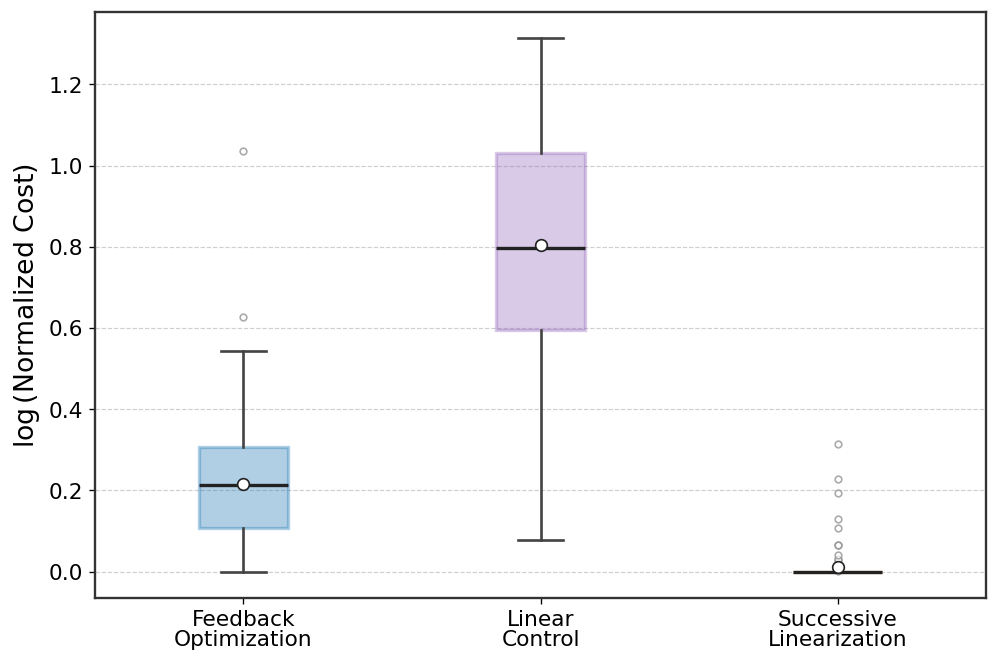


Saved log-normalized mean boxplot to figures_varying/gd_lin_sc_box_lognorm_optmean.pdf


In [19]:
plot_order = ["gd", "lin", "sc"]        
methods    = ["gd", "lin", "sc"]        

xtick_labels_multiline = [
    "Feedback\nOptimization",
    "Linear\nControl",
    "Successive\nLinearization",
]

colors = [
    "#1f77b4",  
    "#9467bd",  
    "#ff7f0e",  
]

name_map = {
    "gd":  "Feedback Optimization",
    "lin": "Linear Control",
    "sc":  "Successive Linearization",
}

def _collect_lognorm_optmean_from_stats3(stats3: dict, eps: float = 1e-12):
    optmean_by_method = {}
    for m in methods:
        key = f"{m}_opt_by_seed"
        if key not in stats3:
            raise KeyError(f"missing '{key}'.")
        A = np.asarray(stats3[key], dtype=float)
        if A.ndim != 2:
            raise ValueError(f"{key} must be 2D, got {A.shape}")
        optmean_by_method[m] = np.nanmean(A, axis=1)

    num_seeds = optmean_by_method[methods[0]].shape[0]
    log_vals_by_method = {m: np.full((num_seeds,), np.nan, dtype=float) for m in methods}

    for i in range(num_seeds):
        vals = {m: float(optmean_by_method[m][i]) for m in methods}
        finite_vals = [v for v in vals.values() if np.isfinite(v)]
        if not finite_vals:
            print(f"Seed {i:02d}: all NaN, skip.")
            continue

        baseline = min(finite_vals)
        for m in methods:
            v = vals[m]
            if not np.isfinite(v):
                log_v = float("nan")
            else:
                log_v = np.log10((v + eps) / (baseline + eps))
            log_vals_by_method[m][i] = log_v

    return log_vals_by_method, optmean_by_method


def plot_box_for_lognorm_optmean(stats3: dict, out_dir: str, filename: str, eps: float = 1e-12):
    log_vals_by_method, optmean_by_method = _collect_lognorm_optmean_from_stats3(stats3, eps=eps)

    data = [log_vals_by_method[m] for m in plot_order]

    print("\n log-normalized mean over seeds:")
    for m in plot_order:
        vals = log_vals_by_method[m]
        print(f"  {name_map[m]:<24}: {float(np.nanmean(vals)) if vals.size else np.nan:.4f}")

    print("\n Raw mean over seeds:")
    for m in plot_order:
        vals = optmean_by_method[m]
        print(f"  {name_map[m]:<24}: {float(np.nanmean(vals)) if vals.size else np.nan:.6g}")

    fig, ax = plt.subplots(figsize=(8.6, 5.8), dpi=120)
    bplot = ax.boxplot(
        data,
        labels=xtick_labels_multiline,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker='o',
            markersize=7,
            markerfacecolor='white',
            markeredgecolor='#222',
            linewidth=1.4
        ),
        medianprops=dict(color='#222', linewidth=2.0),
        whiskerprops=dict(color='#444', linewidth=1.6),
        capprops=dict(color='#444', linewidth=1.6),
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='white',
            markeredgecolor='#888',
            alpha=0.7
        )
    )
    
    for patch, c in zip(bplot["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)
        patch.set_edgecolor(c)
        patch.set_linewidth(2.0)

    ax.set_ylabel(r"$\log$(Normalized Cost)", fontsize=16)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.tick_params(axis="both", labelsize=13)

    plt.setp(ax.get_xticklabels(), ha="center", linespacing=1.0, fontsize=13)
    plt.subplots_adjust(bottom=0.25)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#333")
        ax.spines[side].set_linewidth(1.4)

    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    out_pdf = os.path.join(out_dir, filename)
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"\nSaved log-normalized mean boxplot to {out_pdf}")

plot_box_for_lognorm_optmean(
    stats3=stats3,
    out_dir=out_dir,
    filename="gd_lin_sc_box_lognorm_optmean.pdf",
    eps=1e-12,
)